---
title: "Лабораторна робота 3. Регуляризація в задачах машинного навчання. Стохастичний градінтний спуск з регуляризацією"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "13.03.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: закріпити на практиці використання алгоритмів регуляризації в задачах оптимізації функціонала якості засобами мови Python

## Завдання для самостійної роботи 

1. Повторити приклад апроксимації поліномом для довільної функції, що відрізняється від наведеної у прикладі 1. Проаналізувати результати.
1. Повторити приклад апроксимації поліномом для довільної функції, що відрізняється від наведеної у прикладі 2. Проаналізувати результати.  
1. Побудувати бінарний лінійний-класифікатор з L1-регуляризатором згідно з розглянутим прикладом 3 *для даних свого варіанту*, проаналізувати результати і вивести результати бінарної класифікації на графіку. Імпортувати дані для навчальної вибірки згідно з індивідуальним варіантом (імпорт організувати з файлу).
1. Модифікувати код, де замість L1-регуляризатора має використовуватись L2-регуляризатор. Проаналізувати отримані результати і порівняти їх з попередніми результатами.
1. Дати відповіді на контрольні запитання.
1. Відправити результати роботи у файлі lab_3_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

1. Розглянемо апроксимацію поліномом для функції

$y(x) = x^3 - 8 x^2 + 4x + 700$

In [4]:
import numpy as np

# Функція для передбачення значень поліноміальної моделі
def predict_poly(x, koeff):
    res = 0
    # Обчислення значень для кожного степеня x та відповідного коефіцієнта
    xx = [x ** (len(koeff) - n - 1) for n in range(len(koeff))]

    # Обчислення значення полінома за формулою
    for i, k in enumerate(koeff):
        res += k * xx[i]

    return res

# Створення даних для x та y
x = np.arange(0, 10.1, 0.1)
y = x ** 3 - 8 * x ** 2 + 4 * x + 700 # обчислення значення функції

# Обрання кожної другої точки для тренувальних даних
x_train, y_train = x[::2], y[::2]

N = len(x)

# Підгонка полінома 10-го степеня до тренувальних даних
z_train = np.polyfit(x_train, y_train, 15)
print(z_train)

[-5.40854687e-20  4.06414280e-18 -1.37383078e-16  2.75911210e-15
 -3.66204718e-14  3.38001499e-13 -2.22237575e-12  1.04826500e-11
 -3.52196822e-11  8.24045015e-11 -1.28387716e-10  1.22147449e-10
  1.00000000e+00 -8.00000000e+00  4.00000000e+00  7.00000000e+02]


2. Розглянемо апроксимацію поліномом для функції

$y(x) = x^3 - 8 x^2 + 4x + 700$

[ 6.99180483e+02 -3.51402511e-01 -6.23857829e-01 -8.17150566e-01
 -7.16101518e-01 -1.29871650e-01  4.38210786e-01 -1.98812581e-01
  4.44143634e-02 -5.72478457e-03  4.34155290e-04 -1.80560356e-05
  3.18533664e-07]


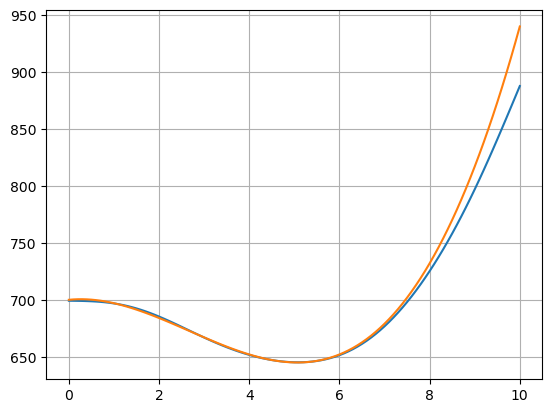

In [2]:
# Приклад роботи регуляризатора L2

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 10.1, 0.1)
y = np.array([a ** 3 - 8 * a ** 2 + 4 * a + 700 for a in x])  # функція у вигляді полінома 
x_train, y_train = x[::2], y[::2]
N = 13  # розмір простору ознак (степінь полінома N-1)
L = 20  # при збільшенні N збільшується L (кратно): 12; 0.2   13; 20    15; 5000

X = np.array([[a ** n for n in range(N)] for a in x])  # матриця вхідних векторів
IL = np.array([[L if i == j else 0 for j in range(N)] for i in range(N)])  # матриця lambda*I
IL[0][0] = 0  # перший коефіцієнт не регуляризується
X_train = X[::2]  # навчальна вибірка
Y = y_train  # навчальна вибірка

# обчислення коефіцієнтів за формулою w = (XT*X + lambda*I)^-1 * XT * Y
A = np.linalg.inv(X_train.T @ X_train + IL) # Тут і нижче @ - оператор точного матричного множення
w = Y @ X_train @ A
print(w)

# відображення початкового графіка та прогнозу
yy = [np.dot(w, x) for x in X]
plt.plot(x, yy) # прогноз моделі
plt.plot(x, y) # справжня поведідка функції
plt.grid(True)
plt.show()


3. Лінійний-класифікатор з L1-регуляризатором

[ 3.85330875e-06  6.48431564e-06  2.27885331e-02 -4.64451568e-02
  6.16881220e-05]
0.01790373090102982


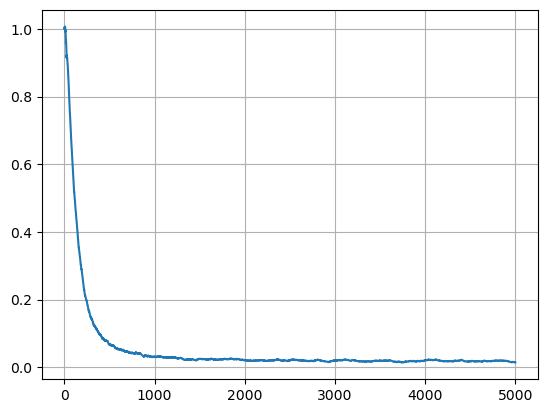

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Сигмоїдна функція втрат
def loss(w, x, y):
    M = np.dot(w, x) * y
    return 2 / (1 + np.exp(M))

# Похідна від сигмоїдальної функції втрат по вектору w
def df(w, x, y):
    L1 = 1.0 # Коефіцієнт L1-регуляризатора 
    M = np.dot(w, x) * y
    return -2 * (1 + np.exp(M)) ** (-2) * np.exp(M) * x * y + L1 * np.sign(w)

# Навчальна вибірка з трьома ознаками (третій - константа +1)
x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [10*x[0], 10*x[1], 5*(x[0]+x[1])] for x in x_train]
x_train = np.array(x_train)
y_train = np.array([-1, 1, 1, -1, -1, -1, 1, -1, 1, 1])

fn = len(x_train[0])
n_train = len(x_train)  # Розмір навчальної вибірки
w = np.zeros(fn)        # Початкові вагові коефіцієнти
nt = 0.00001             # Крок збіжності SGD
lm = 0.01               # Швидкість "забування" для Q
N = 5000                 # Кількість ітерацій SGD

Q = np.mean([loss(x, w, y) for x, y in zip(x_train, y_train)])  # Показник якості
Q_plot = [Q]

# Стохастичний алгоритм градієнтного спуску
for i in range(N):
    k = np.random.randint(0, n_train - 1)       # Випадковий індекс
    ek = loss(w, x_train[k], y_train[k])        # Визначення втрат для обраного вектора
    w = w - nt * df(w, x_train[k], y_train[k])  # Коригування вагів за допомогою SGD
    Q = lm * ek + (1 - lm) * Q                  # Перерахунок показника якості
    Q_plot.append(Q)

Q = np.mean([loss(x, w, y) for x, y in zip(x_train, y_train)]) # Справжнє значення емпіричного ризику після навчання
print(w)
print(Q)

plt.plot(Q_plot)
plt.grid(True)
plt.show()


4. Лінійний-класифікатор з L2-регуляризатором

[ 0.00366119 -0.00590102  0.03661188 -0.05901019 -0.01119915]
0.003970004701937461


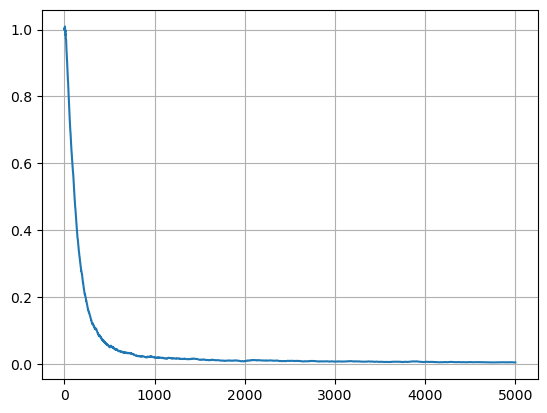

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Сигмоїдна функція втрат
def loss(w, x, y):
    M = np.dot(w, x) * y
    return 2 / (1 + np.exp(M))

# Похідна від функції втрат по вектору w
def df(w, x, y):
    L2 = 1.0 # Коефіцієнт L1-регуляризатора 
    M = np.dot(w, x) * y
    return -2 * (1 + np.exp(M)) ** (-2) * np.exp(M) * x * y + L2 * w

# Навчальна вибірка з трьома ознаками (третій - константа +1)
x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [10*x[0], 10*x[1], 5*(x[0]+x[1])] for x in x_train]
x_train = np.array(x_train)
y_train = np.array([-1, 1, 1, -1, -1, -1, 1, -1, 1, 1])

fn = len(x_train[0])
n_train = len(x_train)  # Розмір навчальної вибірки
w = np.zeros(fn)        # Початкові вагові коефіцієнти
nt = 0.00001             # Крок збіжності SGD
lm = 0.01               # Швидкість "забування" для Q
N = 5000                 # Кількість ітерацій SGD

Q = np.mean([loss(x, w, y) for x, y in zip(x_train, y_train)])  # Показник якості
Q_plot = [Q]

# Стохастичний алгоритм градієнтного спуску
for i in range(N):
    k = np.random.randint(0, n_train - 1)       # Випадковий індекс
    ek = loss(w, x_train[k], y_train[k])        # Визначення втрат для обраного вектора
    w = w - nt * df(w, x_train[k], y_train[k])  # Коригування вагів за допомогою SGD
    Q = lm * ek + (1 - lm) * Q                  # Перерахунок показника якості
    Q_plot.append(Q)

Q = np.mean([loss(x, w, y) for x, y in zip(x_train, y_train)]) # Справжнє значення емпіричного ризику після навчання
print(w)
print(Q)

plt.plot(Q_plot)
plt.grid(True)
plt.show()
